In [1]:
import torch
import torchvision
import random
import matplotlib.pyplot as plt

from torchvision.transforms import v2
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, Subset, random_split, DataLoader
from torchmetrics.detection import MeanAveragePrecision
from matplotlib.patches import Rectangle

In [2]:
base_dataset = torchvision.datasets.Kitti(
    root="./data",
    download=True
)

base_dataset = torchvision.datasets.wrap_dataset_for_transforms_v2(base_dataset)
base_dataset.transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [3]:
model = fasterrcnn_resnet50_fpn_v2(
    weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
)

in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 4

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

In [4]:
class KittiDetectionDataset(Dataset):
    def __init__(self, base_dataset, transforms=None):
        self.base_dataset = base_dataset
        self.transforms = transforms

        self.class_to_id = {
            0: 1,
            1: 1,
            2: 1,
            3: 2,
            5: 3
        }

        self.id_to_name = {
            1: "Vehicle",
            2: "Pedestrian",
            3: "Cyclist",
        }

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, targets = self.base_dataset[idx]

        old_boxes = targets["boxes"]
        old_labels = targets["labels"]

        boxes = []
        labels = []

        for box, label in zip(old_boxes, old_labels):
            label_id = int(label.item())

            if label_id not in self.class_to_id:
                continue

            boxes.append(box)
            labels.append(self.class_to_id[label_id])

        if boxes:
            boxes = torch.stack(boxes)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)

        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(idx)
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target

In [28]:
def draw_bboxes(img, targets):
    _, ax = plt.subplots(figsize=(19, 9))

    img = img.permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ax.axis("off")
    
    color_map = {
        "Vehicle": "red",
        "Pedestrian": "blue",
        "Cyclist": "green",
    }

    for i, (box, label) in enumerate(zip(targets["boxes"], targets["labels"])):
        left, top, right, bottom = box.numpy()

        width = right - left
        height = bottom - top

        label = label.item()
        class_name = dataset.id_to_name[label]
        box_color = color_map.get(class_name, "white")
        
        rectangle = Rectangle(
            (left, top),
            width,
            height,
            fill=False,
            color=box_color,
            linewidth=1.5
        )

        ax.add_patch(rectangle)

        if "scores" in targets:
            score = targets["scores"][i].item()
            ax.text(
                right,
                bottom,
                f"{score * 100:.1f}%",
                fontsize=10,
                color="black",
                ha="right",
                va="bottom",
                bbox={
                    "facecolor": box_color,
                    "alpha": 0.8,
                    "edgecolor": "none",
                    "pad": 2
                }
            )
    plt.show()

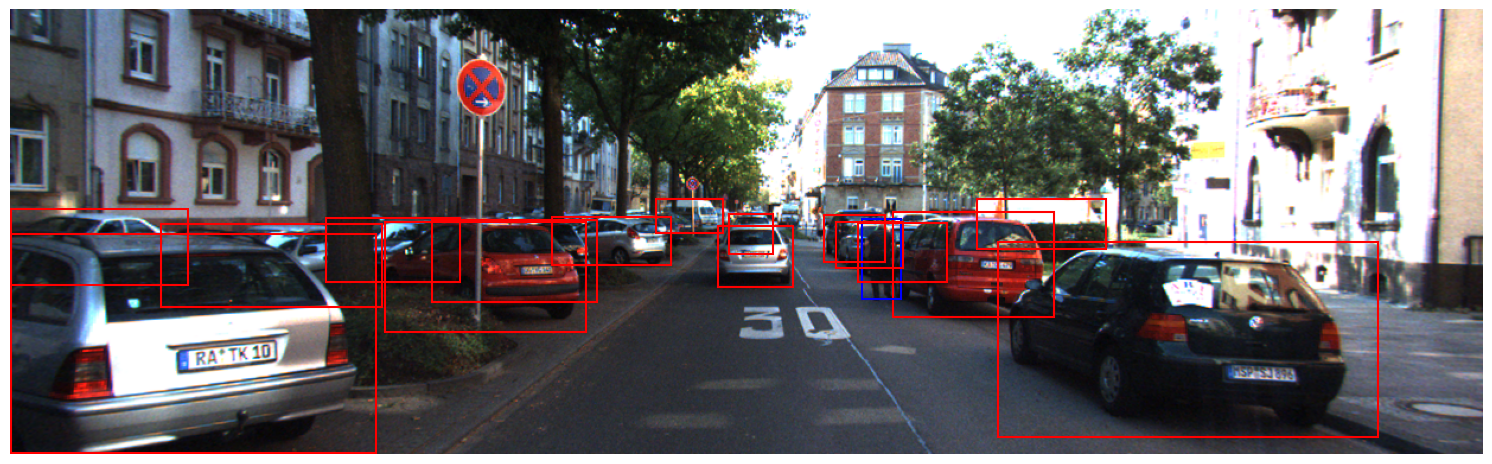

In [87]:
dataset = KittiDetectionDataset(base_dataset)

random_int = random.randint(0, 7480)
img, targets = dataset[random_int]

draw_bboxes(img, targets)


In [7]:
train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size

train_split, val_split = random_split(
    base_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_full_dataset = KittiDetectionDataset(base_dataset, transforms=v2.RandomHorizontalFlip(p=0.5))
val_full_dataset = KittiDetectionDataset(base_dataset, transforms=None)

train_dataset = Subset(train_full_dataset, train_split.indices)
val_dataset = Subset(val_full_dataset, val_split.indices)

In [8]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=8, collate_fn=collate_fn)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

In [10]:
def evaluate(model, val_dataloader, device):
    model.eval()

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        class_metrics=True
    )

    with torch.no_grad():
        for images, targets in val_dataloader:
            images = [image.to(device) for image in images]

            targets = [
                {
                    "boxes": target["boxes"].to(device),
                    "labels": target["labels"].to(device)
                }
                for target in targets
            ]

            predictions = model(images)
            metric.update(predictions, targets)

    results = metric.compute()

    print("mAP:", results["map"].item())
    print("mAP@50:", results["map_50"].item())

    classes = results["classes"].tolist()
    map_per_class = results["map_per_class"].tolist()

    for cls, score in zip(classes, map_per_class):
        print(f"Class {cls} AP: {score:.4f}")
    return results

In [ ]:
num_of_epochs = 10

for epoch in range(num_of_epochs):
    model.train()

    for batch_idx, (images, targets) in enumerate(train_dataloader):
        images = [image.to(device) for image in images]

        targets = [
            {
                key: value.to(device) if torch.is_tensor(value) else value
                for key, value in target.items()
            }
            for target in targets
        ]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            print(
                f"Epoch {epoch + 1}, "
                f"Batch {batch_idx}, "
                f"Loss: {loss.item():.4f}"
            )

    results = evaluate(model, val_dataloader, device)

    print(f"Epoch {epoch + 1} mAP: {results['map'].item():.4f}")
    print(f"Epoch {epoch + 1} mAP@50: {results['map_50'].item():.4f}")

## Model Performance

| Metric | Before Training | After Training |
|---|---:|---:|
| mAP | 0.004 | **0.572** |
| mAP@50 | 0.020 | **0.879** |

In [ ]:
def detect(path):
    img = torchvision.io.decode_image(path)
    scaled_img = v2.functional.to_dtype(img, dtype=torch.float32, scale=True)

    model.eval()
    with torch.no_grad():
        pred = model([scaled_img.to(device)])[0]

    scores = pred["scores"]
    mask = scores >= 0.75

    pred = {k:v[mask].cpu() for k,v in pred.items()}
    draw_bboxes(img, pred)   

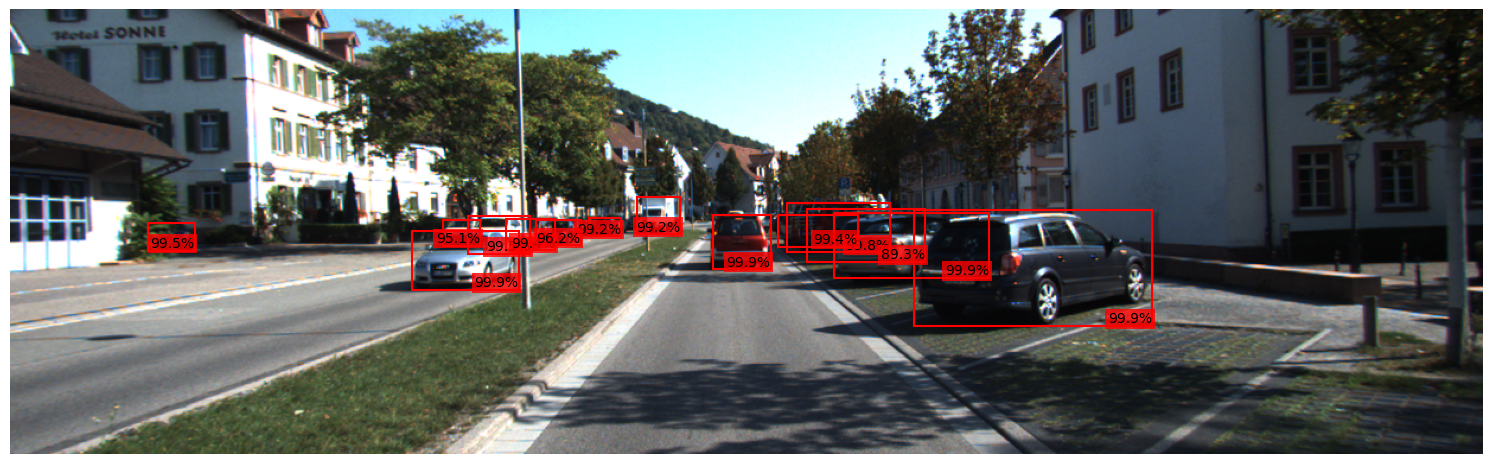

In [36]:
idx = random.choice(val_split.indices)
detect(base_dataset.images[idx])